### Rates Yield

In [26]:
# import packages
from sts.data.database import SymbolTable
from sts.data.yahoo.yhdata import YHData
import datetime
import pandas as pd
import matplotlib.pyplot as plt

In [51]:
symbol_table = SymbolTable()
symbol_table = symbol_table.add_symbol(SymId=0, YahooSym="HG=F", Symbol="copper", AssetClass="Commodity")
symbol_table = symbol_table.add_symbol(SymId=1, YahooSym="GC=F", Symbol="gold", AssetClass="Commodity")
symbol_table = symbol_table.add_symbol(SymId=2, YahooSym="^TNX", Symbol="10Y", AssetClass="Rates")
symbol_table = symbol_table.add_symbol(SymId=3, YahooSym="LBS=F", Symbol="lumber", AssetClass="Commodity")
symbol_table

,YahooSym,AssetClass,Symbol,Description,SymId
0,HG=F,Commodity,copper,None,0
0,GC=F,Commodity,gold,None,1
0,^TNX,Rates,10Y,None,2
0,LBS=F,Commodity,lumber,None,3


In [52]:
yhdata = YHData(symbol_table)

In [77]:
df = yhdata.get_hist_data_for_symbols(["copper", "gold", "10Y"], datetime.date(2015, 1, 1), datetime.date.today())

In [78]:
df["copper_gold_ratio"] = (df["copper"]) / df["gold"] * 1
# df['lumber_gold_ratio'] = df['lumber'] / df['gold']

In [79]:
df.index = pd.to_datetime(df.index).date

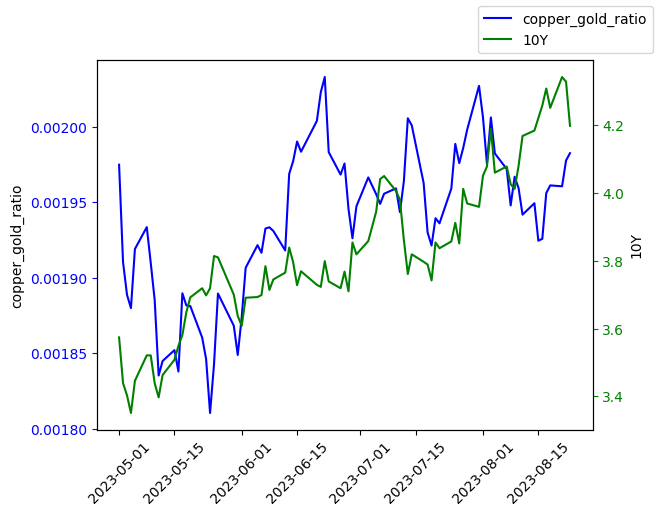

In [81]:
# plots
fig, ax = plt.subplots()
sd = datetime.date(2023, 5, 1)
ed = df.index.max()
cols = ["copper_gold_ratio", "10Y"]
colors = ["blue", "green"]
for col, color, n in zip(cols, colors, range(len(cols))):
    if n == 0:
        df[sd:ed].plot(y=col, ax=ax, color=color, legend=False)
        ax.tick_params(axis="y", colors=color)
        ax.set_ylabel(col)
    else:
        ax2 = ax.twinx()
        # placed on the right by twinx above.
        ax2.spines.right.set_position(("axes", 1 + 0.15 * (n - 1)))
        df[sd:ed].plot(y=col, ax=ax2, color=color, legend=False)
        ax2.tick_params(axis="y", colors=color)
        ax2.set_ylabel(col)
fig.legend(cols)
ax.tick_params(axis="x", rotation=45)